# Parameters

In [1]:
show_intermediate_results = False

# Preparations

## Imports

In [2]:
import polars as pl

playlists = pl.scan_parquet('../processed_data/data_playlist_metadata.parquet')
playlist_tracks = pl.scan_parquet('../processed_data/data_playlist_songs.parquet')
tracks = pl.scan_parquet('../processed_data/data_song_metadata.parquet')

## Source Data

In [3]:
playlists.collect() if show_intermediate_results else None

In [4]:
playlist_tracks.collect() if show_intermediate_results else None

In [5]:
tracks.collect()  if show_intermediate_results else None

# Analysis

## Tokenization

In [6]:
def tokenize(expr: pl.Expr) -> pl.Expr:
    return expr.str.to_lowercase().str.split(' ')

def tokenize_unique(expr: pl.Expr) -> pl.Expr:
    return tokenize(expr)\
        .list.filter(pl.element().ne(''))\
        .list.unique(maintain_order=True)

## Keyword statistics

Step 1: Tokenize the playlist names by splitting on whitespaces.

We currently turn every word into its own separate keyword term.
As a later optimization, it might make sense to treat words most often
occuring together (e.g. `late night`) to make the output more useful.

In [7]:
playlists_tokenized = playlists.select(
    pl.col('playlist.id'),
    pl.col('playlist.name'),
    pl.col('playlist.name').pipe(tokenize_unique).alias('unique_terms'),
)

playlists_tokenized.collect(engine='streaming') if show_intermediate_results else None

Step 2: Aggregate over playlist terms

In [8]:
exploded_playlists_tokenized = playlists_tokenized\
    .explode('unique_terms')\
    .rename({'unique_terms': 'term'})

exploded_playlists_tokenized.limit(100).collect(engine='streaming') if show_intermediate_results else None

In [9]:
tokens = exploded_playlists_tokenized\
    .group_by('term')\
    .agg(pl.col('term').count().alias('playlist_count'))\
    .sort('playlist_count', descending=True)

Review query plan for potential performance/memory problems:

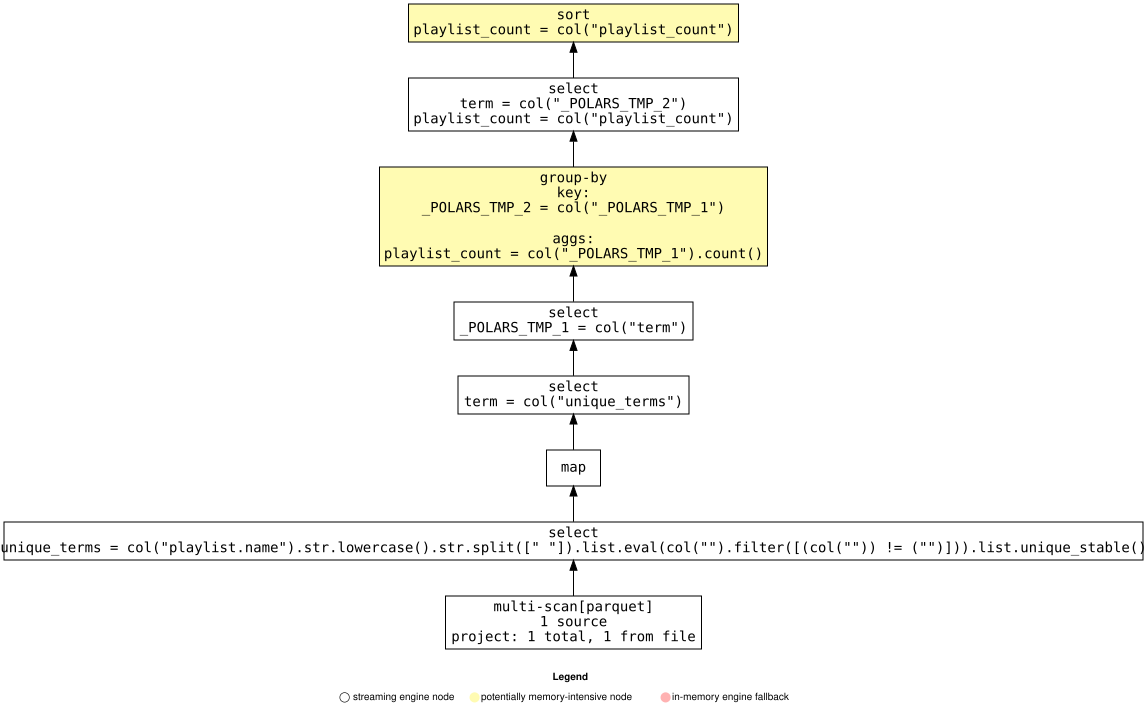

In [10]:
tokens.show_graph(plan_stage='physical', engine='streaming', optimized=True)

In [11]:
tokens.filter(pl.col('playlist_count').ge(100)).collect(engine='streaming')

term,playlist_count
str,u32
"""wcs""",14539
"""-""",6276
"""swing""",2652
"""blues""",1961
"""bpm""",1957
…,…
"""intermediate""",102
"""cool""",102
"""mar""",102


In [12]:
# Write to CSV
# tokens.filter(pl.col('playlist_count').ge(20)).sink_csv('playlist_keywords.csv', engine='streaming')

The following discoveries where made when manually reviewing the CSV data:

- Also split on & remove common punctuation (`(`, `)`, `[`, `]`,`:`, `#` etc.)
- Remove certain common words that do not provide any information:
  - on
  - by
  - with
  - at
  - and
  - a
  - I
  - ...
- Unify `90's`/`90s` etc.
- Unify `bday`/`birthday`/`b-day` etc.
- Check correlations between consecutive words

## Keyword <=> Song correlations

Ignore tokens that appear only a few types to reduce the size of the `join`/`group_by`.

In [13]:
tokens\
    .filter(pl.col('playlist_count').le(5))\
    .group_by(pl.col('playlist_count').alias('max_playlist_count'))\
    .agg(pl.col('playlist_count').count().alias('num_terms'))\
    .sort('max_playlist_count')\
    .collect(engine='streaming')

max_playlist_count,num_terms
u32,u32
0,1
1,30813
2,5803
3,2345
4,1293
5,845


In [ ]:
relevant_tokens = tokens\
    .filter(pl.col('playlist_count').ge(5))\
    .collect(engine='streaming')

track_keywords = playlist_tracks\
    .join(exploded_playlists_tokenized.join(relevant_tokens.lazy(), how='semi', on='term'), how='inner', on='playlist.id')\
    .group_by('track.id', 'term')\
    .agg(pl.col('term').count().alias('playlist_count'))

track_keywords.limit(50).collect(engine='streaming') if show_intermediate_results else None

track.id,term,playlist_count
str,str,u32
"""6gTyFBUwTXmCSWFln6p0Nl""","""hear""",1
"""2UOsvtsqMiqsFgaDPvJmcI""","""old""",10
"""2dRvMEW4EwySxRUtEamSfG""","""by""",18
"""2dRvMEW4EwySxRUtEamSfG""","""old""",5
"""4hI1dTlDeXUL9dIYH0ikWR""","""old""",4
…,…,…
"""5nDfqxqoMN6h3EkWJYnpVh""","""wcs""",220
"""09J3NVQcf22QNl23QPOZbe""","""105-109""",2
"""0Q7ncgjbFaRHnToXsSS3Gr""","""wcse""",1


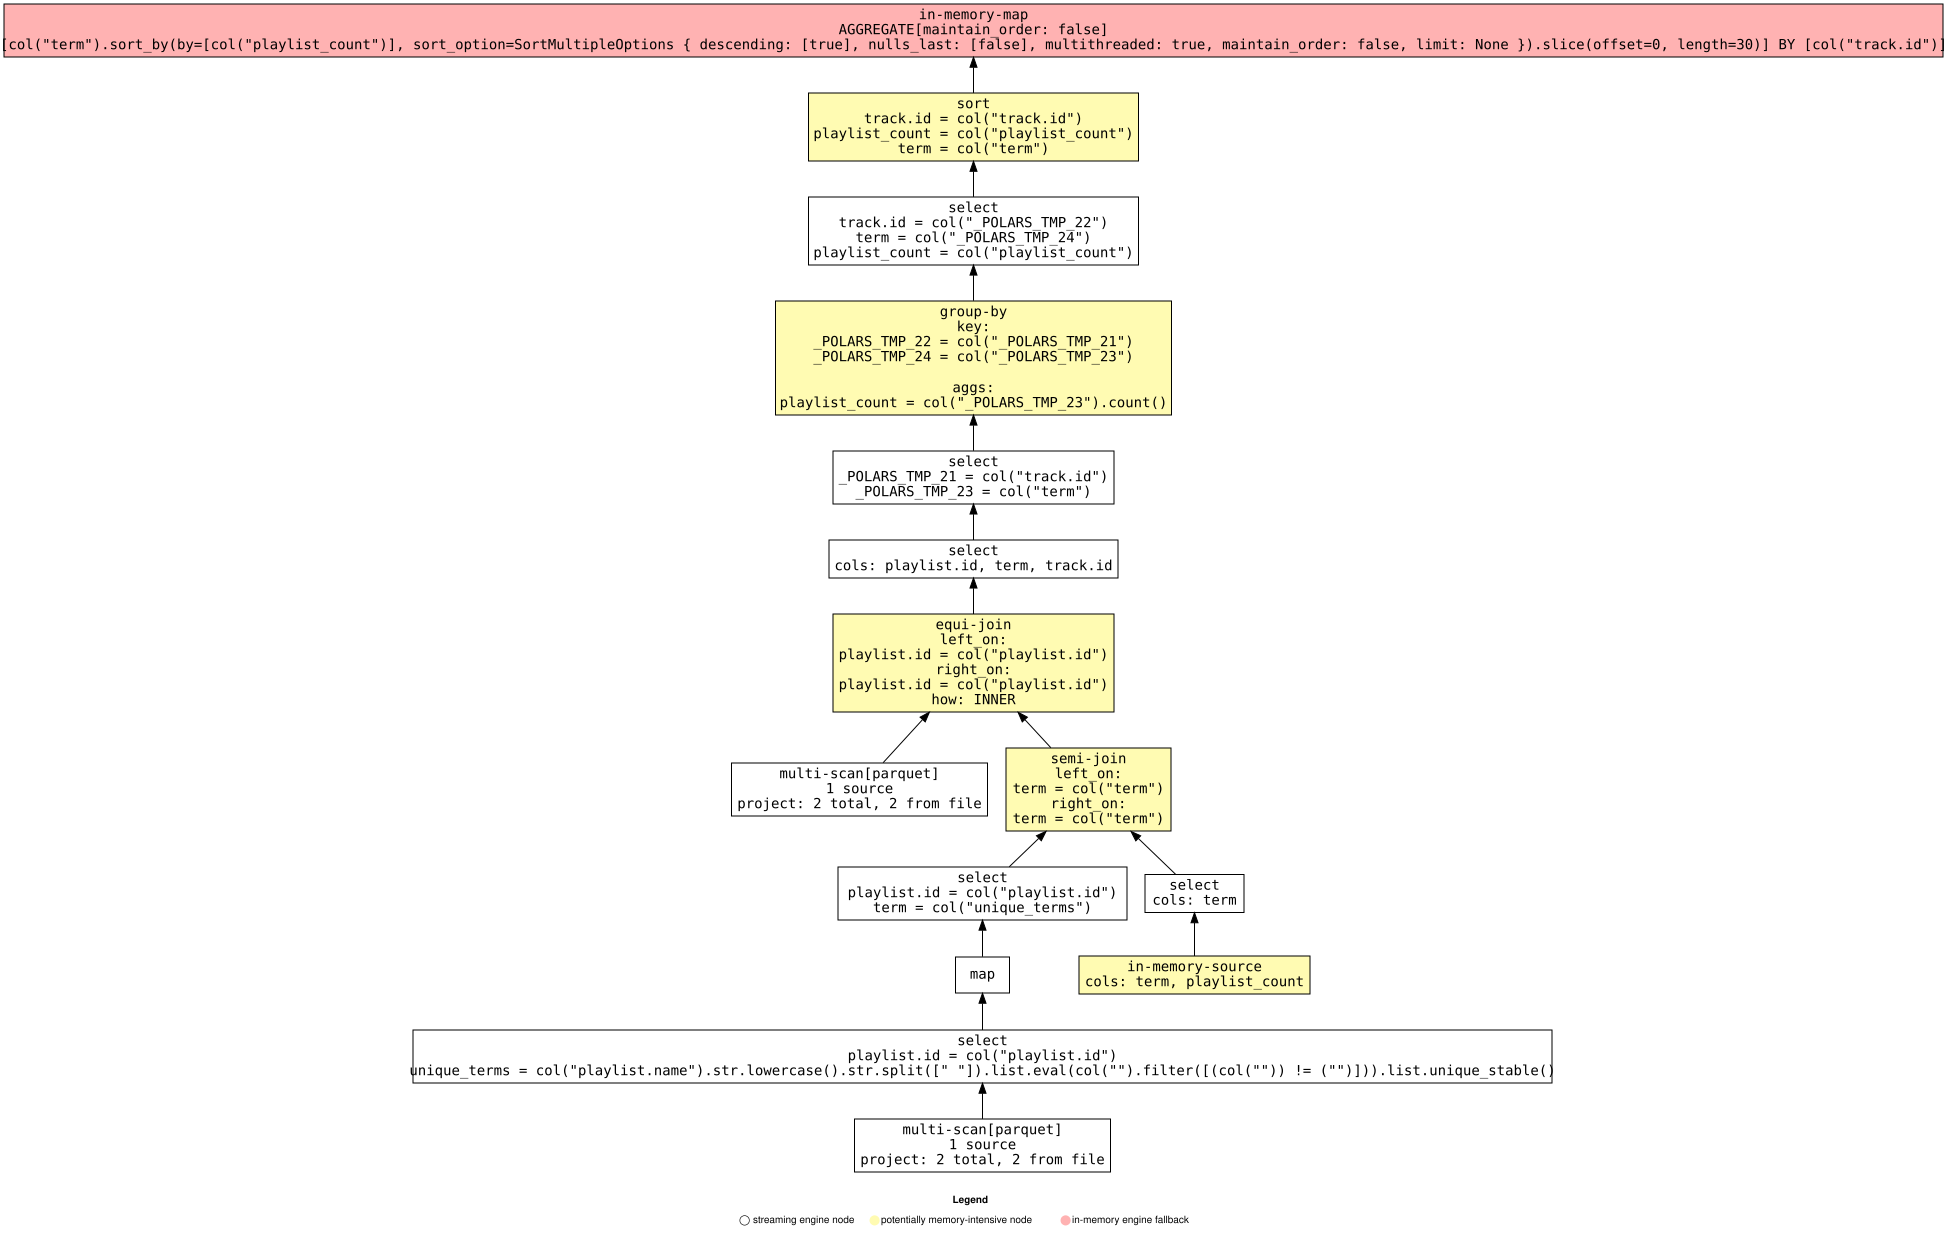

In [15]:
q = track_keywords\
    .sort('track.id', 'playlist_count', 'term')\
    .group_by('track.id')\
    .agg(pl.col('term').sort_by('playlist_count', descending=True).head(30))

q.show_graph(plan_stage='physical', engine='streaming', optimized=True)

In [ ]:
# q = track_keywords\
#     .sort('track.id', 'playlist_count', 'term')\
#     .group_by('track.id')\
#     .agg(pl.col('term').first())

q = track_keywords.count()

# q.show_graph(plan_stage='physical', engine='streaming', optimized=True)

q.collect() if show_intermediate_results else None

track.id,term,playlist_count
u32,u32,u32
4552852,4552852,4552852


In [17]:
temp_file = 'temp_track_keywords.parquet'
track_keywords.sink_parquet(temp_file)
track_keywords = pl.scan_parquet(temp_file)

In [18]:
temp_file = 'temp_track_keywords_by_track_id.parquet'
track_keywords_by_track_id = track_keywords.sort('track.id')
track_keywords_by_track_id.sink_parquet(temp_file)
track_keywords_by_track_id = pl.scan_parquet(temp_file)

In [19]:
track_keywords_grouped_by_track_id = track_keywords_by_track_id\
    .join(tracks.slice(20, 20).select('track.id').cache(), how='semi', on='track.id')\
    .group_by('track.id')\
    .agg(pl.col('term').sort_by('playlist_count', descending=True).head(20),
         pl.col('playlist_count').sort(descending=True).head(20).alias('playlist_counts'),
         pl.col('playlist_count').sort(descending=True).head(20).sum())\
    .join(tracks.select('track.id', 'track.name', 'track.artists'), how='inner', on='track.id')

# track_keywords_grouped_by_track_id.show_graph(plan_stage='physical', engine='streaming', optimized=True)
track_keywords_grouped_by_track_id.collect()

track.id,term,playlist_counts,playlist_count,track.name,track.artists
str,list[str],list[u32],u32,str,list[str]
"""002pgO1R2952phPuujFoOE""","[""wcs"", ""-"", … ""2""]","[96, 19, … 5]",268,"""WOW""","[""Zara Larsson""]"
"""002wNT6cMCf0N93MUC1fwM""","[""wcs"", ""intro"", … ""no""]","[5, 2, … 1]",25,"""Alone""","[""Will Gittens""]"
"""0032P9X3AD4AQvN7yzpmTo""","[""coast"", ""swing"", … ""bpm""]","[3, 3, … 1]",26,"""Middle""","[""Jessame"", ""Sean Turk""]"
"""0037eQ5YPvX3aHBrLGVmB9""","[""songs"", ""playlist"", … ""liked""]","[2, 2, … 2]",14,"""The Day After You Said Goodbye""","[""SURAN""]"
"""003CBfF5s2kwaGSdJt3WkQ""","[""wasda"", ""playlist"", … ""wednesday""]","[3, 2, … 1]",30,"""BOOTS 'N ALL""","[""Kaylee Bell""]"
…,…,…,…,…,…
"""004HWXFltpet1VoUuRW4Om""","[""iii"", ""the"", … ""fan""]","[1, 1, … 1]",4,"""Fireflower""","[""jeremy messersmith""]"
"""004LyfCBQmqMcg8QD0zpbR""","[""wcs"", ""june"", … ""thursday""]","[3, 1, … 1]",16,"""Mexico""","[""Gamma Skies"", ""Amaranthine""]"
"""004XT7kCZUEJkVIZjmBdDi""","[""smoke"", ""dance"", … ""the""]","[1, 1, … 1]",6,"""Life Rolls On""","[""Slightly Stoopid""]"


Using `group_by` to aggregate a column into a list is currently not supported by Polars' `streaming` engine.
To avoid crashing with an OOM, we sequentially process batches of `track.id`s instead:

In [ ]:
import math


def process_track_keywords_batch(tracks_batch: pl.LazyFrame) -> pl.LazyFrame:
    return track_keywords_by_track_id\
        .join(tracks_batch, how='semi', on='track.id')\
        .group_by('track.id')\
        .agg(pl.col('term').sort_by('playlist_count', descending=True).head(20),
             pl.col('playlist_count').sort(descending=True).head(20).alias('playlist_counts'),
             pl.col('playlist_count').sort(descending=True).head(20).sum())\
        .join(tracks_batch.select('track.id', 'track.name', 'track.artists'), how='inner', on='track.id')


def process_track_keywords_in_batches():
    row_count = tracks.select(pl.len()).collect().item()
    batch_size = 5000  # Higher batch sizes are faster but have a righer OOM risk
    batch_count = int(math.ceil(row_count / batch_size))

    print(f"Processing {row_count:,} tracks in {batch_count:,} batches of {batch_size:,} items...")

    for batch_index in range(0, batch_count):
        batch_start = batch_index * batch_size
        print(f"Processing batch {batch_index:,}/{batch_count:,}")
        batch_result = process_track_keywords_batch(tracks.slice(batch_start, batch_size))\
            .sort('track.id')
        batch_result.sink_parquet(f'temp_batch_{batch_index}.parquet')

    print("Merging batches...")

    merged: pl.LazyFrame | None = None
    for batch_index in range(0, batch_count):
        batch_data = pl.scan_parquet(f'temp_batch_{batch_index}.parquet')
        merged = (batch_data if merged is None else
                  merged.merge_sorted(batch_data, 'track.id'))

    merged.sink_parquet('temp_keywords_by_track.parquet')

    print("Done.")


process_track_keywords_in_batches()

Processing 203,709 tracks in 41 batches of 5,000 items...
Merging batches...


Done.


In [24]:
keywords_by_track = pl.scan_parquet('temp_keywords_by_track.parquet')

keywords_by_track.limit(1000).collect()

track.id,term,playlist_counts,playlist_count,track.name,track.artists
str,list[str],list[u32],u32,str,list[str]
"""000CC8EParg64OmTxVnZ0p""","[""glee"", ""musical"", … ""glow""]","[1, 1, … 1]",4,"""It's All Coming Back To Me Now…","[""Glee Cast""]"
"""000N4CJL8IjQ0f2I4grgBO""","[""spring"", ""a"", … ""2025""]","[1, 1, … 1]",4,"""Girl Next Door""","[""Ayra Starr"", ""Tyla""]"
"""000TJlEJQ3nafsm1hBWpoj""","[""tyler"", ""the"", … ""mode""]","[1, 1, … 1]",4,"""LEMONHEAD (feat. 42 Dugg)""","[""42 Dugg"", ""Tyler, The Creator""]"
"""000uPbEAb9tlFkCJ1DIOcw""","[""tina"", ""favoriter"", … ""lista""]","[1, 1, … 1]",10,"""Kom""","[""Timoteij""]"
"""000xQL6tZNLJzIrtIgxqSl""","[""wcs"", ""shazam"", … ""dj""]","[18, 9, … 2]",79,"""Still Got Time (feat. PARTYNEX…","[""ZAYN"", ""PARTYNEXTDOOR""]"
…,…,…,…,…,…
"""01tA4XmJ4fGQNwti6b2hPm""","[""wcs"", ""swing"", … ""2020""]","[57, 17, … 4]",227,"""The Git Up""","[""Blanco Brown""]"
"""01tAaocelNOxIXGaEMBjul""","[""wcs"", ""favs"", … ""background""]","[7, 2, … 1]",34,"""Genesis""","[""Ne-Yo"", ""Step Up: High Water""]"
"""01tMS0uOOkkfFg88P9QPq2""","[""contemporain"", ""rainbow"", … ""_""]","[1, 1, … 1]",6,"""Feathers""","[""Kupla""]"
